Imports

In [31]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Framework de Deep Learning et utilitaires de vision par ordinateur
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Métriques d'évaluation et protocoles de segmentation de données
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# Gestion de la progression des processus itératifs
from tqdm import tqdm

def set_seed(seed=42):
    """
    Assure la reproductibilité des résultats en fixant les graines aléatoires 
    pour les différentes bibliothèques utilisées.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Désactivation des algorithmes non-déterministes de CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initialisation de la reproductibilité et sélection du périphérique de calcul
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Système configuré sur : {device}")

Système configuré sur : cpu


Prétraitement des images : Recadrage et mise au format carré standardisé

In [32]:
def crop_to_square(img, threshold=10):
    """Recadre au plus près et ajoute du padding noir pour rester carré."""
    img_gray = img.convert('L')
    img_np = np.array(img_gray)
    coords = np.argwhere(img_np > threshold)
    if coords.size == 0: return img.resize((224, 224))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    brain_crop = img.crop((x_min, y_min, x_max, y_max))
    width, height = brain_crop.size
    max_side = max(width, height)
    square_img = Image.new("RGB", (max_side, max_side), (0, 0, 0))
    square_img.paste(brain_crop, ((max_side - width) // 2, (max_side - height) // 2))
    return square_img.resize((224, 224))

In [33]:
# Chargement des jeux de données séparés issus du Notebook 3
train_df = pd.read_pickle("../features/train_weak_labels.pkl")
val_df = pd.read_pickle("../features/val_weak_labels.pkl")
test_df = pd.read_pickle("../features/test_weak_labels.pkl")

# Normalisation des étiquettes (0: normal, 1: cancer)
label_map = {'normal': 0, 'cancer': 1}
for df in [train_df, val_df, test_df]:
    mask = df['label'] != 'Unknown'
    df.loc[mask, 'true_label_idx'] = df.loc[mask, 'label'].map(label_map)

# Préparation des sous-ensembles
# Strong (experts) : uniquement les données connues de l'entraînement
train_strong_df = train_df[train_df['label'] != 'Unknown'].copy()
train_strong_df['target'] = train_strong_df['true_label_idx'].astype(int)

# Validation et Test
val_df['target'] = val_df['true_label_idx'].astype(int)
test_df['target'] = test_df['true_label_idx'].astype(int)

# Weak : les données non étiquetées de l'entraînement (utilise K-Means)
df_weak = train_df[train_df['label'] == 'Unknown'].copy()
df_weak['target'] = df_weak['weak_label'].astype(int)

print(f"Volume des datasets (séparation stricte respectée) :")
print(f"- Entraînement 'Strong' : {len(train_strong_df)} images")
print(f"- Entraînement 'Weak' : {len(df_weak)} images")
print(f"- Validation : {len(val_df)} images")
print(f"- Test : {len(test_df)} images")

Volume des datasets (séparation stricte respectée) :
- Entraînement 'Strong' : 59 images
- Entraînement 'Weak' : 1402 images
- Validation : 10 images
- Test : 30 images


Import des datas

Constitution du jeu de test de référence (Hold-out Set)

Préparation des sous-ensembles d'entraînement pour le protocole semi-supervisé

Pipeline d'entraînement

In [34]:
#  inclut l'augmentation pour la robustesse du modèle
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pipeline de validation/test : aucune transformation aléatoire pour garantir la reproductibilité
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Création de la classe Dataset personnalisée pour la gestion des images et des étiquettes

In [35]:
class BrainMRIDataset(Dataset):
    """
    Dataset optimisé pour l'entraînement du CNN.
    Charge les images, applique le recadrage (Crop) et les transformations.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Chargement et prétraitement géométrique (standardisation du cadrage)
        image = Image.open(row['path']).convert('RGB')
        
        # Note : On réutilise ici la fonction crop_to_square définie précédemment 
        # pour assurer la cohérence avec l'extraction des features.
        image = crop_to_square(image)
        
        if self.transform:
            image = self.transform(image)
            
        # La cible 'target' est l'index numérique (0 ou 1)
        target = torch.tensor(row['target'], dtype=torch.long)
        
        return image, target

Instanciation des Datasets et configuration des DataLoaders par lots (Batches)

In [36]:
# Configuration des hyperparamètres de chargement
BATCH_SIZE = 32

# Création des objets Dataset
weak_train_set = BrainMRIDataset(df_weak, transform=train_transform)
strong_train_set = BrainMRIDataset(train_strong_df, transform=train_transform)
val_set = BrainMRIDataset(val_df, transform=test_transform) # Aucune augmentation sur la validation
test_set = BrainMRIDataset(test_df, transform=test_transform) # Aucune augmentation sur le test

# Initialisation des DataLoaders
weak_loader = DataLoader(weak_train_set, batch_size=BATCH_SIZE, shuffle=True)
strong_loader = DataLoader(strong_train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders configurés (Train Weak, Train Strong, Validation, Test).")

DataLoaders configurés (Train Weak, Train Strong, Validation, Test).


Configuration de l'architecture ResNet18

In [37]:
def get_brain_model(num_classes=2, freeze_base=True):
    """
    Initialise un modèle ResNet18 pré-entraîné et adapte la couche de sortie 
    pour la classification binaire (Normal vs Cancer).
    """
    # Chargement du modèle avec les poids issus d'ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Gel des poids de base (on empêche la mémorisation immédiate)
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
            
    # Remplacement de la couche Fully Connected (FC)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

# Initialisation du modèle de test
model = get_brain_model().to(device)

print(f"Modèle ResNet18 initialisé et configuré pour {device}.")

Modèle ResNet18 initialisé et configuré pour cpu.


Configuration de la fonction de perte (Loss) et de l'algorithme d'optimisation

In [38]:
# Fonction de coût : CrossEntropyLoss est le standard pour la classification multi-classe
# Elle gère automatiquement l'application de la fonction Softmax en sortie
criterion = nn.CrossEntropyLoss()

# Optimiseur : Adam est privilégié pour sa gestion adaptative du taux d'apprentissage (learning rate)
# Un learning rate faible (1e-4) assure une convergence stable lors du fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Fonction de perte et Optimiseur configurés.")

Fonction de perte et Optimiseur configurés.


Définition des procédures fondamentales : Cycles d'entraînement (Train) et d'évaluation (Eval)

In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Exécute une itération complète sur l'ensemble du jeu de données d'entraînement.
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        # Réinitialisation des gradients
        optimizer.zero_grad()

        # Passage avant (Forward pass)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Rétropropagation et optimisation
        loss.backward()
        optimizer.step()

        # Statistiques
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

def evaluate_model(model, loader, criterion, device):
    """
    Évalue la performance du modèle sur un jeu de données de test ou de validation.
    Le calcul des gradients est désactivé pour optimiser les ressources.
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    return val_loss, val_acc, val_f1

Orchestration de l'entraînement global et suivi de l'historique des métriques de performance

In [40]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def run_training_session(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=30, patience=5):
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    early_stopping = EarlyStopping(patience=patience)
    
    for epoch in range(num_epochs):
        t_loss, t_acc, t_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, v_f1 = evaluate_model(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['train_f1'].append(t_f1)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['val_f1'].append(v_f1)
        
        print(f"Époque {epoch+1:02d}/{num_epochs} | Train F1: {t_f1:.4f} - Val F1: {v_f1:.4f} | Val Loss: {v_loss:.4f}")
        
        early_stopping(v_loss)
        if early_stopping.early_stop:
            print(f"Arrêt prématuré déclenché à l'époque {epoch+1} (Surapprentissage détecté).")
            break
            
    return history

In [41]:
def plot_learning_curves(history, title="Learning Curves"):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Courbe de Loss
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    ax1.set_title(f'{title} - Évolution de la Perte')
    ax1.set_xlabel('Époques')
    ax1.set_ylabel('Loss (CrossEntropy)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Courbe de F1-Score
    ax2.plot(epochs, history['train_f1'], label='Train F1', marker='o')
    ax2.plot(epochs, history['val_f1'], label='Validation F1', marker='o')
    ax2.set_title(f'{title} - Évolution du F1-Score')
    ax2.set_xlabel('Époques')
    ax2.set_ylabel('F1-Score (Weighted)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

Implémentation de la validation croisée stratifiée (Stratified K-Fold) pour l'évaluation de la Baseline

Lancement

Entraînement du modèle de référence (Baseline) en mode supervisé pur sur les données expertes

 DÉMARRAGE DE LA RECHERCHE D'HYPERPARAMÈTRES (GRID SEARCH) 

--- Test du Learning Rate : 0.001 ---


Époque 01/30 | Train F1: 0.3503 - Val F1: 0.4949 | Val Loss: 0.7556


Époque 02/30 | Train F1: 0.3606 - Val F1: 0.6703 | Val Loss: 0.6984


Époque 03/30 | Train F1: 0.5650 - Val F1: 0.4949 | Val Loss: 0.6428


Époque 04/30 | Train F1: 0.6761 - Val F1: 0.5833 | Val Loss: 0.6084


...

Époque 01/30 | Train F1: 0.4047 - Val F1: 0.3333 | Val Loss: 0.7339


Époque 02/30 | Train F1: 0.4258 - Val F1: 0.3333 | Val Loss: 0.7242


Époque 03/30 | Train F1: 0.3699 - Val F1: 0.3333 | Val Loss: 0.7260


Époque 04/30 | Train F1: 0.5154 - Val F1: 0.3333 | Val Loss: 0.7300


Époque 05/30 | Train F1: 0.4258 - Val F1: 0.2857 | Val Loss: 0.7242
Arrêt prématuré déclenché à l'époque 5 (Surapprentissage détecté).
--> Meilleur Val F1 pour LR=1e-05 : 0.3333

 BILAN DU GRID SEARCH 
🏆 Le meilleur Learning Rate est : 0.001
Score F1 Validation associé : 1.0000


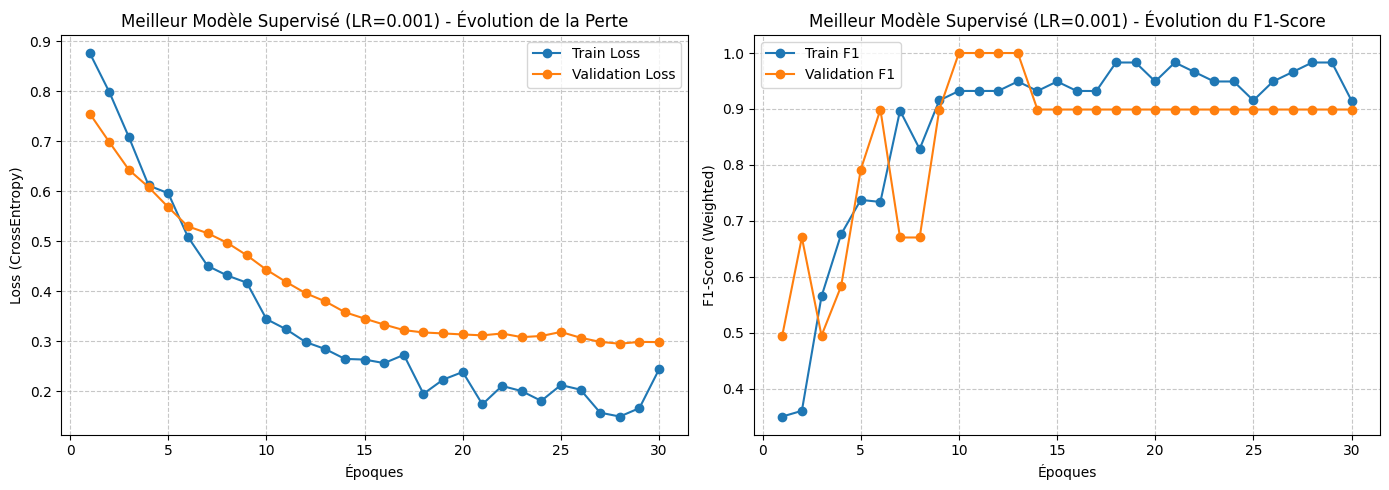

<All keys matched successfully>

In [42]:
# 1. Définir la grille de recherche (les valeurs de Learning Rate à tester)
# On teste des valeurs logarithmiques classiques
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

best_overall_f1 = 0
best_lr = None
best_history = None
best_model_state = None

print("="*60)
print(" DÉMARRAGE DE LA RECHERCHE D'HYPERPARAMÈTRES (GRID SEARCH) ")
print("="*60)

for lr in learning_rates:
    print(f"\n--- Test du Learning Rate : {lr} ---")
    
    # ÉTAPE CRUCIALE : Toujours instancier un NOUVEAU modèle pour chaque test
    # Sinon, le modèle continue d'apprendre sur les poids du test précédent !
    model_cv = get_brain_model(freeze_base=True).to(device)
    
    # On met à jour l'optimiseur avec le LR courant (on garde la régularisation L2)
    optimizer_cv = optim.Adam(model_cv.parameters(), lr=lr, weight_decay=1e-3)
    
    # Lancement de l'entraînement pour ce LR
    # On réduit un peu la patience pour accélérer le balayage
    history = run_training_session(
        model=model_cv,
        train_loader=strong_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_cv,
        device=device,
        num_epochs=30, 
        patience=3  
    )
    
    # On cherche le meilleur score F1 atteint sur la validation pendant cet entraînement
    best_val_f1_for_this_lr = max(history['val_f1'])
    print(f"--> Meilleur Val F1 pour LR={lr} : {best_val_f1_for_this_lr:.4f}")
    
    # Si c'est notre nouveau record, on sauvegarde les infos
    if best_val_f1_for_this_lr > best_overall_f1:
        best_overall_f1 = best_val_f1_for_this_lr
        best_lr = lr
        best_history = history
        # On sauvegarde les poids du modèle vainqueur
        best_model_state = model_cv.state_dict()

print("\n" + "="*60)
print(" BILAN DU GRID SEARCH ")
print("="*60)
print(f"🏆 Le meilleur Learning Rate est : {best_lr}")
print(f"Score F1 Validation associé : {best_overall_f1:.4f}")
print("="*60)

# Tracé des courbes du gagnant
plot_learning_curves(best_history, f"Meilleur Modèle Supervisé (LR={best_lr})")

# On recharge les poids du meilleur modèle dans "model_supervised" pour la suite du notebook
model_supervised = get_brain_model(freeze_base=True).to(device)
model_supervised.load_state_dict(best_model_state)

Mise en œuvre de l'approche hybride : Pré-entraînement sur étiquettes faibles et fine-tuning sur étiquettes expertes

 GRID SEARCH : APPROCHE HYBRIDE (PHASES 1 & 2) 

--- Test LR Phase 1 : 0.001 | LR Phase 2 : 0.0001 ---
-> Phase 1 (Weak Labels)...


Époque 01/15 | Train F1: 0.9144 - Val F1: 0.1667 | Val Loss: 3.1441


Époque 02/15 | Train F1: 0.9508 - Val F1: 0.1667 | Val Loss: 4.6890


Époque 03/15 | Train F1: 0.9693 - Val F1: 0.1667 | Val Loss: 4.5185


Époque 04/15 | Train F1: 0.9565 - Val F1: 0.0909 | Val Loss: 6.4733
Arrêt prématuré déclenché à l'époque 4 (Surapprentissage détecté).
-> Réinitialisation de la couche de classification...
-> Phase 2 (Strong Labels)...


...

Époque 36/40 | Train F1: 0.9830 - Val F1: 1.0000 | Val Loss: 0.0642


Époque 37/40 | Train F1: 1.0000 - Val F1: 1.0000 | Val Loss: 0.0614


Époque 38/40 | Train F1: 1.0000 - Val F1: 1.0000 | Val Loss: 0.0591


Époque 39/40 | Train F1: 1.0000 - Val F1: 1.0000 | Val Loss: 0.0568


Époque 40/40 | Train F1: 1.0000 - Val F1: 1.0000 | Val Loss: 0.0555
--> Meilleur Val F1 final pour ce test : 1.0000

 BILAN DU GRID SEARCH HYBRIDE 
🏆 Meilleur LR Phase 1 : 0.0005 (Phase 2 : 5e-05)
Score F1 Validation associé : 1.0000


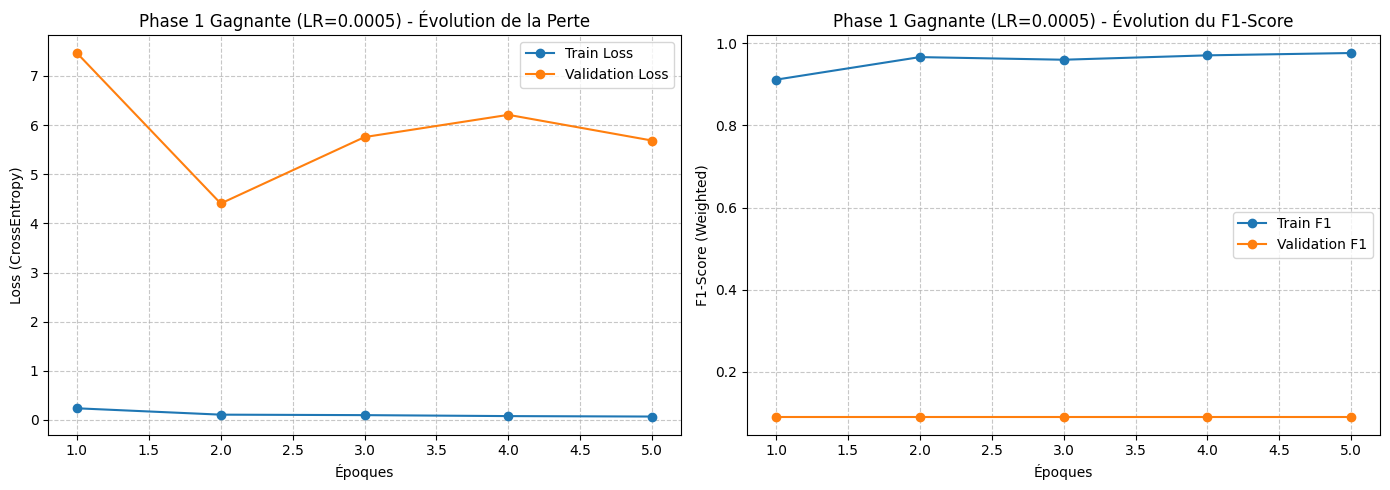

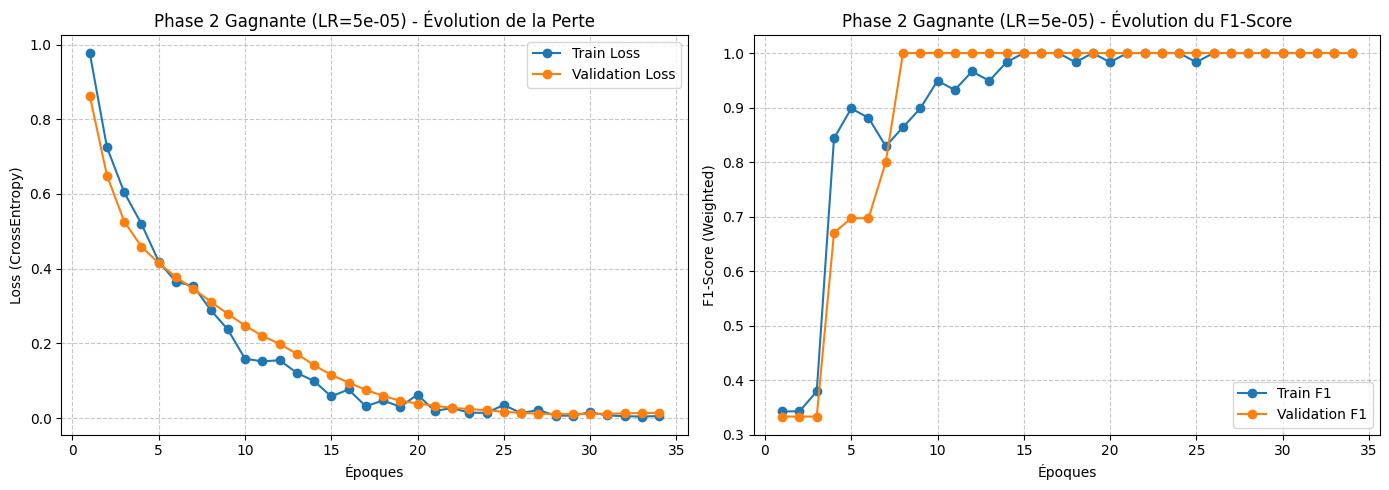

<All keys matched successfully>

In [43]:
# Définition des taux d'apprentissage à tester pour la Phase 1
pretrain_lrs = [1e-3, 5e-4, 1e-4]

best_hybrid_f1 = 0
best_hybrid_lr = None
best_hybrid_history_pt = None
best_hybrid_history_ft = None
best_hybrid_model_state = None

print("="*60)
print(" GRID SEARCH : APPROCHE HYBRIDE (PHASES 1 & 2) ")
print("="*60)

for lr_pre in pretrain_lrs:
    lr_fine = lr_pre / 10
    print(f"\n--- Test LR Phase 1 : {lr_pre} | LR Phase 2 : {lr_fine} ---")
    
    # 1. Dégel complet (freeze_base=False) pour adapter les convolutions aux IRM
    model_cv = get_brain_model(freeze_base=False).to(device)
    optimizer_cv = optim.Adam(model_cv.parameters(), lr=lr_pre, weight_decay=1e-3)
    
    # 2. Phase 1 : Pré-entraînement sur étiquettes faibles (Apprentissage des textures)
    print("-> Phase 1 (Weak Labels)...")
    history_pt = run_training_session(
        model=model_cv,
        train_loader=weak_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_cv,
        device=device,
        num_epochs=15,
        patience=3
    )
    
    # 3. Transition stratégique : On coupe la "tête" biaisée par le K-Means et on en met une neuve
    print("-> Réinitialisation de la couche de classification...")
    num_ftrs = model_cv.fc.in_features
    model_cv.fc = nn.Linear(num_ftrs, 2).to(device)
    
    # On recrée un optimiseur propre pour la Phase 2 avec le nouveau Learning Rate
    optimizer_ft = optim.Adam(model_cv.parameters(), lr=lr_fine, weight_decay=1e-3)
    
    # 4. Phase 2 : Fine-tuning sur étiquettes expertes
    print("-> Phase 2 (Strong Labels)...")
    history_ft = run_training_session(
        model=model_cv,
        train_loader=strong_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_ft,
        device=device,
        num_epochs=40,
        patience=5
    )
    
    # 5. Évaluation
    best_val_f1_ft = max(history_ft['val_f1'])
    print(f"--> Meilleur Val F1 final pour ce test : {best_val_f1_ft:.4f}")
    
    if best_val_f1_ft > best_hybrid_f1:
        best_hybrid_f1 = best_val_f1_ft
        best_hybrid_lr = lr_pre
        best_hybrid_history_pt = history_pt
        best_hybrid_history_ft = history_ft
        best_hybrid_model_state = model_cv.state_dict()

print("\n" + "="*60)
print(" BILAN DU GRID SEARCH HYBRIDE ")
print("="*60)
print(f"🏆 Meilleur LR Phase 1 : {best_hybrid_lr} (Phase 2 : {best_hybrid_lr / 10})")
print(f"Score F1 Validation associé : {best_hybrid_f1:.4f}")
print("="*60)

# Tracé des courbes d'apprentissage
plot_learning_curves(best_hybrid_history_pt, f"Phase 1 Gagnante (LR={best_hybrid_lr})")
plot_learning_curves(best_hybrid_history_ft, f"Phase 2 Gagnante (LR={best_hybrid_lr / 10})")

# Restauration des poids finaux
model_semi_sup = get_brain_model(freeze_base=False).to(device)
model_semi_sup.load_state_dict(best_hybrid_model_state)

Évaluation comparative des performances : Matrices de confusion et rapports de classification détaillés

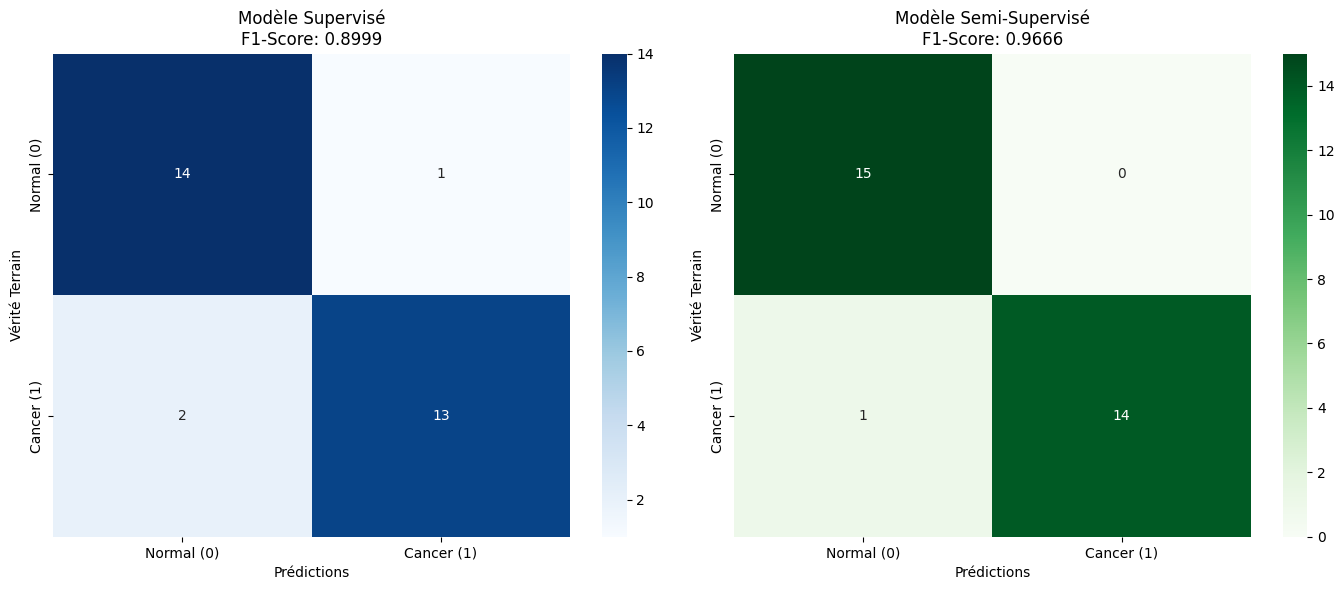


--- RAPPORT MODÈLE SUPERVISÉ ---
              precision    recall  f1-score   support

  Normal (0)       0.88      0.93      0.90        15
  Cancer (1)       0.93      0.87      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


--- RAPPORT MODÈLE SEMI-SUPERVISÉ ---
              precision    recall  f1-score   support

  Normal (0)       0.94      1.00      0.97        15
  Cancer (1)       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [44]:
def get_predictions(model, loader, device):
    """Extrait les étiquettes réelles et les prédictions d'un modèle pour un DataLoader."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())
    return y_true, y_pred

# Extraction des prédictions sur le jeu de test (jamais vu lors de l'entraînement)
y_true, y_pred_sup = get_predictions(model_supervised, test_loader, device)
_, y_pred_semi = get_predictions(model_semi_sup, test_loader, device)

# Configuration de l'affichage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['Normal (0)', 'Cancer (1)']

# Matrice 1 : Modèle Supervisé
cm_sup = confusion_matrix(y_true, y_pred_sup)
sns.heatmap(cm_sup, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f"Modèle Supervisé\nF1-Score: {f1_score(y_true, y_pred_sup, average='weighted'):.4f}")
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédictions')

# Matrice 2 : Modèle Semi-Supervisé
cm_semi = confusion_matrix(y_true, y_pred_semi)
sns.heatmap(cm_semi, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f"Modèle Semi-Supervisé\nF1-Score: {f1_score(y_true, y_pred_semi, average='weighted'):.4f}")
axes[1].set_ylabel('Vérité Terrain')
axes[1].set_xlabel('Prédictions')

plt.tight_layout()
plt.show()

# Affichage des rapports de classification complets
print("\n--- RAPPORT MODÈLE SUPERVISÉ ---")
print(classification_report(y_true, y_pred_sup, target_names=class_names))

print("\n--- RAPPORT MODÈLE SEMI-SUPERVISÉ ---")
print(classification_report(y_true, y_pred_semi, target_names=class_names))

Synthèse comparative et calcul de l'évolution des performances (Gain F1-Score)

In [45]:
# Calcul du gain de performance final
f1_final_sup = f1_score(y_true, y_pred_sup, average='weighted')
f1_final_semi = f1_score(y_true, y_pred_semi, average='weighted')

gain_f1 = ((f1_final_semi - f1_final_sup) / f1_final_sup) * 100

vol_classique = len(train_strong_df)
vol_hybride = len(train_strong_df) + len(df_weak)

print("="*60)
print(" BILAN DE L'EXPÉRIMENTATION ")
print("="*60)
print(f"Performance approche classique ({vol_classique} img) : {f1_final_sup:.4f}")
print(f"Performance approche hybride ({vol_hybride} img) : {f1_final_semi:.4f}")
print("-"*60)
print(f"ÉVOLUTION GLOBALE DU MODÈLE : {gain_f1:+.2f} %")
print("="*60)

 BILAN DE L'EXPÉRIMENTATION 
Performance approche classique (59 img) : 0.8999
Performance approche hybride (1461 img) : 0.9666
------------------------------------------------------------
ÉVOLUTION GLOBALE DU MODÈLE : +7.42 %
